In [37]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
df = pd.read_csv('../../data/children_products/children_product_cleaned_full_year.csv')

print(f"Размер исходного датасета: {df.shape}")
df.head()

Размер исходного датасета: (4050261, 17)


,Дата,НомерЗаказаНаСайте,МетодДоставки,Группа2,Группа3,Тип,Отменено,Количество,Цена,МесяцДаты Заказа,Статус,Гео,Маржа,СуммаУслуг,Телефон_new,ID_SKU,МетодДоставки_Групп
0,2017-01-01 17:15:00,3530280_TR,Магазины,"ТЕКСТИЛЬ, ТРИКОТАЖ","ГОЛОВНЫЕ УБОРЫ, ВАРЕЖКИ, ПЕРЧАТКИ",ОДЕЖДА,Нет,1,1400.0,1.0,Возврат,Москва,374.87,0,55575454-49504949555170,IDL00023865048,Магазины
1,2017-01-01 17:15:00,3530280_TR,Магазины,"ТЕКСТИЛЬ, ТРИКОТАЖ","ГОЛОВНЫЕ УБОРЫ, ВАРЕЖКИ, ПЕРЧАТКИ",ОДЕЖДА,Нет,1,1400.0,1.0,Возврат,Москва,374.87,0,55575454-49504949555170,IDL00022519452,Магазины
2,2017-01-01 17:38:00,3530303_TR,Курьерская,ПОДГУЗНИКИ,ПОДГУЗНИКИ,ППКП,Нет,3,1195.0,1.0,Доставлен,Москва,122.25,0,55574851-55555555555176,IDL00038454553,Курьерская
3,2017-01-01 17:38:00,3530318_TR,Магазины,"ТЕКСТИЛЬ, ТРИКОТАЖ",ВЕРХНЯЯ ДЕТСКАЯ ОДЕЖДА,ОДЕЖДА,Нет,1,2510.0,1.0,Доставлен,Москва,282.94,0,55575054-56575354545171,IDL00035301654,Магазины
4,2017-01-01 17:38:00,3530313_TR,Самовывоз,ИГРУШКИ,КОНСТРУКТОРЫ,ИГРУШКИ,Нет,1,1069.0,1.0,Доставлен,Регионы,83.97,0,55575149-50524951545076,ID9010025983048,Магазины


In [39]:
df.info()
print("Уникальные значения статуса:")
print(df['Статус'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4050261 entries, 0 to 4050260
Data columns (total 17 columns):
 #   Column               Dtype  
---  ------               -----  
 0   Дата                 object 
 1   НомерЗаказаНаСайте   object 
 2   МетодДоставки        object 
 3   Группа2              object 
 4   Группа3              object 
 5   Тип                  object 
 6   Отменено             object 
 7   Количество           int64  
 8   Цена                 float64
 9   МесяцДаты Заказа     float64
 10  Статус               object 
 11  Гео                  object 
 12  Маржа                float64
 13  СуммаУслуг           int64  
 14  Телефон_new          object 
 15  ID_SKU               object 
 16  МетодДоставки_Групп  object 
dtypes: float64(3), int64(2), object(12)
memory usage: 525.3+ MB
Уникальные значения статуса:
Статус
Доставлен       2754078
Возврат          796700
Отменен          380943
В процессе        98823
Не определен      19717
Name: count, dtype: 

In [40]:
df_filtered = df[(df['Статус'] == 'Доставлен') & (df['Отменено'] == 'Нет')].copy()

print(f"Размер после фильтрации (только 'Доставлен'): {df_filtered.shape}")
print(f"Удалено записей: {len(df) - len(df_filtered)}")

Размер после фильтрации (только 'Доставлен'): (2649178, 17)
Удалено записей: 1401083


In [41]:
print("Пропущенные значения в ключевых колонках:")
print(df_filtered[['Телефон_new', 'ID_SKU', 'Дата']].isnull().sum())

df_filtered = df_filtered.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])
print(f"\nРазмер после удаления пропусков: {df_filtered.shape}")

Пропущенные значения в ключевых колонках:
Телефон_new    595626
ID_SKU         596051
Дата                0
dtype: int64

Размер после удаления пропусков: (2053127, 17)


In [42]:
df_filtered['Дата'] = pd.to_datetime(df_filtered['Дата'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['Дата'])
print(f"Диапазон дат: {df_filtered['Дата'].min()} - {df_filtered['Дата'].max()}")
print(f"Размер после обработки дат: {df_filtered.shape}")

Диапазон дат: 2017-01-01 17:38:00 - 2017-12-01 19:48:00
Размер после обработки дат: (2053127, 17)


In [43]:
MIN_INTERACTIONS = 5

for iteration in range(5):
    user_counts = df_filtered.groupby('Телефон_new').size()
    item_counts = df_filtered.groupby('ID_SKU').size()
    active_users = user_counts[user_counts >= MIN_INTERACTIONS].index
    active_items = item_counts[item_counts >= MIN_INTERACTIONS].index
    before = len(df_filtered)
    df_filtered = df_filtered[
        df_filtered['Телефон_new'].isin(active_users) &
        df_filtered['ID_SKU'].isin(active_items)
    ]
    if len(df_filtered) == before:
        break

n_users = df_filtered['Телефон_new'].nunique()
n_items = df_filtered['ID_SKU'].nunique()
n_interactions = len(df_filtered)
density = n_interactions / (n_users * n_items) * 100
print(f"После фильтрации (≥{MIN_INTERACTIONS} покупок):")
print(f"  Пользователей: {n_users:,}, Товаров: {n_items:,}")
print(f"  Взаимодействий: {n_interactions:,}")
print(f"  Плотность матрицы: {density:.4f}%")

После фильтрации (≥5 покупок):
  Пользователей: 81,845, Товаров: 41,010
  Взаимодействий: 1,437,235
  Плотность матрицы: 0.0428%


Статистика покупок на пользователя:
count    81845.000000
mean        17.560450
std         24.086825
min          4.000000
25%          6.000000
50%         10.000000
75%         19.000000
max        756.000000
dtype: float64


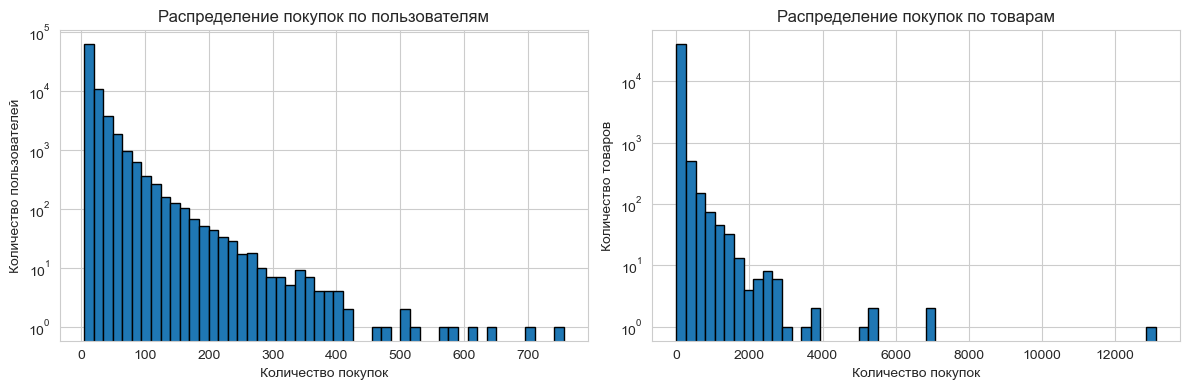

In [44]:
user_purchases = df_filtered.groupby('Телефон_new').size()

print("Статистика покупок на пользователя:")
print(user_purchases.describe())

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(user_purchases, bins=50, edgecolor='black')
plt.xlabel('Количество покупок')
plt.ylabel('Количество пользователей')
plt.title('Распределение покупок по пользователям')
plt.yscale('log')

plt.subplot(1, 2, 2)
item_purchases = df_filtered.groupby('ID_SKU').size()
plt.hist(item_purchases, bins=50, edgecolor='black')
plt.xlabel('Количество покупок')
plt.ylabel('Количество товаров')
plt.title('Распределение покупок по товарам')
plt.yscale('log')

plt.tight_layout()
plt.show()

In [45]:
interactions = df_filtered.groupby(['Телефон_new', 'ID_SKU']).size().reset_index(name='count')

print(f"Количество уникальных пар (пользователь, товар): {len(interactions):,}")
print(f"Среднее количество покупок одного товара пользователем: {interactions['count'].mean():.2f}")
interactions.head()

Количество уникальных пар (пользователь, товар): 1,250,933
Среднее количество покупок одного товара пользователем: 1.15


,Телефон_new,ID_SKU,count
0,32555749-545749525150 .,ID000sn-5681048,1
1,32555749-545749525150 .,ID110000017654,1
2,32555749-545749525150 .,ID110000017755,1
3,32555749-545749525150 .,ID110000017856,1
4,32555749-545749525150 .,ID9010001872856,1


In [46]:
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

interactions['user_id'] = user_encoder.fit_transform(interactions['Телефон_new'])
interactions['item_id'] = item_encoder.fit_transform(interactions['ID_SKU'])

user_id_to_phone = dict(zip(interactions['user_id'], interactions['Телефон_new']))
item_id_to_sku = dict(zip(interactions['item_id'], interactions['ID_SKU']))

interactions.head()

,Телефон_new,ID_SKU,count,user_id,item_id
0,32555749-545749525150 .,ID000sn-5681048,1,0,1361
1,32555749-545749525150 .,ID110000017654,1,0,4255
2,32555749-545749525150 .,ID110000017755,1,0,4256
3,32555749-545749525150 .,ID110000017856,1,0,4257
4,32555749-545749525150 .,ID9010001872856,1,0,5727


In [47]:
interactions_with_date = df_filtered.merge(
    interactions[['Телефон_new', 'ID_SKU', 'user_id', 'item_id', 'count']],
    on=['Телефон_new', 'ID_SKU'],
    how='inner'
)
interactions_with_date = interactions_with_date.sort_values('Дата')
print(f"Размер данных с датами: {len(interactions_with_date):,}")
interactions_with_date.head()

Размер данных с датами: 1,437,235


,Дата,НомерЗаказаНаСайте,МетодДоставки,Группа2,Группа3,Тип,Отменено,Количество,Цена,МесяцДаты Заказа,Статус,Гео,Маржа,СуммаУслуг,Телефон_new,ID_SKU,МетодДоставки_Групп,user_id,item_id,count
0,2017-01-01 17:38:00,3530314_TR,Самовывоз,ПОДГУЗНИКИ,ПОДГУЗНИКИ,ППКП,Нет,1,1199.0,1.0,Доставлен,Регионы,99.00,0,55575051-49495453545474,IDL00018187149,Магазины,44022,13156,1
1,2017-01-01 17:56:00,3530368_TR,Курьерская,ОБУВЬ,ОБУВЬ ДЕТСКАЯ,ОДЕЖДА,Нет,1,1188.0,1.0,Доставлен,Москва,657.95,0,55575054-49565150514977,IDL00022382654,Курьерская,49700,14405,1
2,2017-01-01 19:30:00,3530615_TR,Магазины,ИГРУШКИ,ИГРУШКИ ДЛЯ РАЗВИТИЯ МАЛЫШЕЙ,ИГРУШКИ,Нет,1,267.0,1.0,Доставлен,Регионы,99.91,99,55574854-57545652574976,IDL00007574856,Магазины,13364,10227,1
3,2017-01-01 20:12:00,3530741_TR,Магазины,ТОВАРЫ ДЛЯ КОРМЛЕНИЯ,ПОСУДА,ППКП,Нет,1,535.0,1.0,Доставлен,Москва,170.00,49,55575456-56525650504871,IDL00028679755,Магазины,74851,17440,1
4,2017-01-02 10:10:00,2018000083_TR,Магазины,КРУПНОГАБАРИТНЫЙ ТОВАР,КОЛЯСКИ,КГТ,Нет,1,24700.0,1.0,Доставлен,Регионы,8296.00,0,55574848-51494850484970,IDL00011945351,Магазины,91,11621,1


In [48]:
split_date = interactions_with_date['Дата'].quantile(0.8)

print(f"Дата разделения: {split_date}")
print(f"Train: до {split_date}")
print(f"Test: после {split_date}")

train_data = interactions_with_date[interactions_with_date['Дата'] < split_date].copy()
test_data = interactions_with_date[interactions_with_date['Дата'] >= split_date].copy()

print(f"\nРазмер train: {len(train_data):,} ({len(train_data)/len(interactions_with_date)*100:.1f}%)")
print(f"Размер test: {len(test_data):,} ({len(test_data)/len(interactions_with_date)*100:.1f}%)")

Дата разделения: 2017-09-04 22:25:00
Train: до 2017-09-04 22:25:00
Test: после 2017-09-04 22:25:00

Размер train: 1,149,773 (80.0%)
Размер test: 287,462 (20.0%)


In [49]:
train_interactions = train_data.groupby(['user_id', 'item_id'])['count'].sum().reset_index()
test_interactions = test_data.groupby(['user_id', 'item_id'])['count'].sum().reset_index()

print(f"Уникальных взаимодействий в train: {len(train_interactions):,}")
print(f"Уникальных взаимодействий в test: {len(test_interactions):,}")

test_users = set(test_interactions['user_id'].unique())
test_items = set(test_interactions['item_id'].unique())
train_users = set(train_interactions['user_id'].unique())
train_items = set(train_interactions['item_id'].unique())

print(f"Пользователей в train: {len(train_users):,}")
print(f"Пользователей в test: {len(test_users):,}")
print(f"Пользователей только в test (cold start): {len(test_users - train_users):,}")
print(f"Товаров в train: {len(train_items):,}")
print(f"Товаров в test: {len(test_items):,}")
print(f"Товаров только в test (cold start): {len(test_items - train_items):,}")

Уникальных взаимодействий в train: 1,008,139
Уникальных взаимодействий в test: 269,448
Пользователей в train: 73,070
Пользователей в test: 33,172
Пользователей только в test (cold start): 8,775
Товаров в train: 40,150
Товаров в test: 29,337
Товаров только в test (cold start): 860


In [50]:
def create_sparse_matrix(interactions_df, n_users, n_items):
    return csr_matrix(
        (interactions_df['count'].values,
         (interactions_df['user_id'].values, interactions_df['item_id'].values)),
        shape=(n_users, n_items)
    )

n_users = len(user_encoder.classes_)
n_items = len(item_encoder.classes_)

train_matrix = create_sparse_matrix(train_interactions, n_users, n_items)
test_matrix = create_sparse_matrix(test_interactions, n_users, n_items)

print(f"Размер train матрицы: {train_matrix.shape}")
print(f"Ненулевых элементов в train: {train_matrix.nnz:,}")
print(f"Плотность train матрицы: {train_matrix.nnz / (n_users * n_items) * 100:.4f}%")
print(f"Размер test матрицы: {test_matrix.shape}")
print(f"Ненулевых элементов в test: {test_matrix.nnz:,}")

Размер train матрицы: (81845, 41010)
Ненулевых элементов в train: 1,008,139
Плотность train матрицы: 0.0300%
Размер test матрицы: (81845, 41010)
Ненулевых элементов в test: 269,448


In [51]:
model = AlternatingLeastSquares(
    factors=50,
    regularization=0.01,
    iterations=15,
    calculate_training_loss=True,
    random_state=42
)

In [52]:
model.fit(train_matrix)

  0%|          | 0/15 [00:00<?, ?it/s]

In [53]:
def get_recommendations(model, user_id, train_matrix, n_items, k=10, filter_already_liked=True):
    item_ids, scores = model.recommend(
        user_id,
        train_matrix[user_id],
        N=k,
        filter_already_liked_items=filter_already_liked
    )
    return list(item_ids), list(scores)

test_user_id = 0
rec_items, rec_scores = get_recommendations(model, test_user_id, train_matrix, n_items, k=5)

for item_id, score in zip(rec_items, rec_scores):
    print(f"Товар {item_id} (SKU: {item_id_to_sku.get(item_id, 'N/A')}): {score:.4f}")

Товар 3477 (SKU: ID10011698048): 0.0033
Товар 652 (SKU: ID000sm-4475048): 0.0026
Товар 651 (SKU: ID000sm-4474149): 0.0022
Товар 3480 (SKU: ID10011698351): 0.0016
Товар 3478 (SKU: ID10011698149): 0.0015


In [54]:
def precision_at_k(recommended_items, relevant_items, k):
    recommended_k = set(recommended_items[:k])
    relevant = set(relevant_items)
    if not recommended_k:
        return 0.0
    return len(recommended_k & relevant) / len(recommended_k)

def recall_at_k(recommended_items, relevant_items, k):
    recommended_k = set(recommended_items[:k])
    relevant = set(relevant_items)
    if not relevant:
        return 0.0
    return len(recommended_k & relevant) / len(relevant)

def map_at_k(recommended_items, relevant_items, k):
    relevant = set(relevant_items)
    if not relevant:
        return 0.0
    score = 0.0
    num_hits = 0.0
    for i, item in enumerate(recommended_items[:k]):
        if item in relevant:
            num_hits += 1.0
            score += num_hits / (i + 1.0)
    return score / min(len(relevant), k)

def ndcg_at_k(recommended_items, relevant_items, k):
    relevant = set(relevant_items)
    if not relevant:
        return 0.0
    dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(recommended_items[:k]) if item in relevant)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

In [55]:
def evaluate_model(model, train_matrix, test_interactions, k_values=[5, 10, 20]):
    test_user_items = test_interactions.groupby('user_id')['item_id'].apply(list).to_dict()
    train_users = set(np.where(train_matrix.getnnz(axis=1) > 0)[0])
    test_users = [u for u in test_user_items.keys() if u in train_users]

    print(f"Оценка на {len(test_users):,} пользователях...")

    results = {k: {'precision': [], 'recall': [], 'map': [], 'ndcg': []} for k in k_values}

    for user_id in test_users:
        try:
            rec_items, _ = get_recommendations(
                model, user_id, train_matrix, train_matrix.shape[1],
                k=max(k_values), filter_already_liked=True
            )
            relevant_items = test_user_items[user_id]
            for k in k_values:
                results[k]['precision'].append(precision_at_k(rec_items, relevant_items, k))
                results[k]['recall'].append(recall_at_k(rec_items, relevant_items, k))
                results[k]['map'].append(map_at_k(rec_items, relevant_items, k))
                results[k]['ndcg'].append(ndcg_at_k(rec_items, relevant_items, k))
        except Exception:
            continue

    return {
        k: {m: np.mean(v) for m, v in metrics.items()}
        for k, metrics in results.items()
    }

In [56]:
k_values = [5, 10, 20]
results = evaluate_model(model, train_matrix, test_interactions, k_values=k_values)

for k in k_values:
    print(f"\nМетрики для K={k}:")
    print(f"  Precision@{k}: {results[k]['precision']:.4f}")
    print(f"  Recall@{k}:    {results[k]['recall']:.4f}")
    print(f"  MAP@{k}:       {results[k]['map']:.4f}")
    print(f"  NDCG@{k}:      {results[k]['ndcg']:.4f}")

Оценка на 24,397 пользователях...

Метрики для K=5:
  Precision@5: 0.0346
  Recall@5:    0.0350
  MAP@5:       0.0295
  NDCG@5:      0.0468

Метрики для K=10:
  Precision@10: 0.0262
  Recall@10:    0.0488
  MAP@10:       0.0267
  NDCG@10:      0.0481

Метрики для K=20:
  Precision@20: 0.0190
  Recall@20:    0.0645
  MAP@20:       0.0260
  NDCG@20:      0.0514


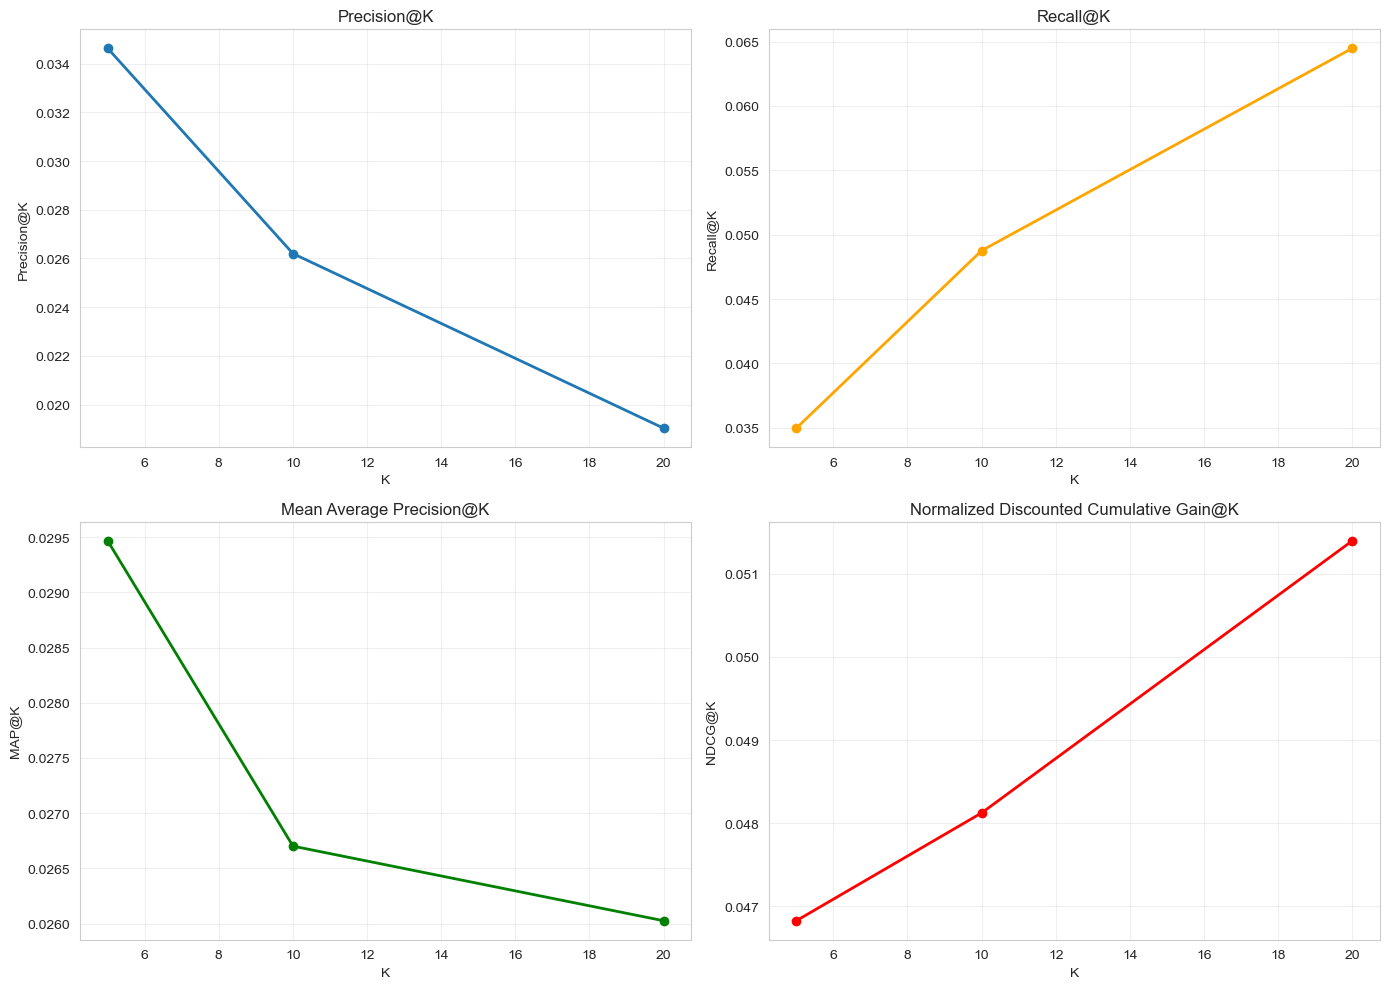

In [57]:
metrics_df = pd.DataFrame(results).T
metrics_df.index.name = 'K'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(metrics_df.index, metrics_df['precision'], marker='o', linewidth=2)
axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('Precision@K')
axes[0, 0].set_title('Precision@K'); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(metrics_df.index, metrics_df['recall'], marker='o', linewidth=2, color='orange')
axes[0, 1].set_xlabel('K'); axes[0, 1].set_ylabel('Recall@K')
axes[0, 1].set_title('Recall@K'); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(metrics_df.index, metrics_df['map'], marker='o', linewidth=2, color='green')
axes[1, 0].set_xlabel('K'); axes[1, 0].set_ylabel('MAP@K')
axes[1, 0].set_title('Mean Average Precision@K'); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(metrics_df.index, metrics_df['ndcg'], marker='o', linewidth=2, color='red')
axes[1, 1].set_xlabel('K'); axes[1, 1].set_ylabel('NDCG@K')
axes[1, 1].set_title('Normalized Discounted Cumulative Gain@K'); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()